# Hostel Complaints Analysis
Exploring the `hostel_complaints_800_final (1).csv` dataset.

In [24]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('hostel_complaints_800_final (1).csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (800, 13)


,Complaint_ID,Complaint_Text,Complaint_Type,Block,Floor,Room_No,Category,Duration,Students_Affected,Support_Count,Priority,Status,Complaint_Date
0,C0001,"Hi, theres cobwebs all over the staircase.",Public,B,First,15,Cleanliness,since this evening,23,2,Low,Resolved,01-05-2026
1,C0002,My washroom door doesnt lock properly because ...,Public,C,First,15,Washroom,since yesterday,1,0,Low,Pending,01-05-2026
2,C0003,The milk served at breakfast smelled slightly ...,Public,C,Ground,4,Mess,since this morning,2,1,High,Pending,01-05-2026
3,C0004,"Mess timing keeps changing without any notice,...",Public,C,Second,23,Mess,since 30 minutes,53,20,Medium,In Progress,01-05-2026
4,C0005,"Theres cobwebs all over the staircase, doesnt ...",Public,B,First,14,Cleanliness,since Monday,37,17,Medium,Pending,01-05-2026


In [25]:
# Basic info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Complaint_ID       800 non-null    str  
 1   Complaint_Text     800 non-null    str  
 2   Complaint_Type     800 non-null    str  
 3   Block              800 non-null    str  
 4   Floor              800 non-null    str  
 5   Room_No            800 non-null    int64
 6   Category           800 non-null    str  
 7   Duration           800 non-null    str  
 8   Students_Affected  800 non-null    int64
 9   Support_Count      800 non-null    int64
 10  Priority           800 non-null    str  
 11  Status             800 non-null    str  
 12  Complaint_Date     800 non-null    str  
dtypes: int64(3), str(10)
memory usage: 81.4 KB


In [26]:
# Summary statistics
df.describe(include='all')

,Complaint_ID,Complaint_Text,Complaint_Type,Block,Floor,Room_No,Category,Duration,Students_Affected,Support_Count,Priority,Status,Complaint_Date
count,800,800,800,800,800,800.000000,800,800,800.000000,800.000000,800,800,800
unique,800,800,2,3,5,NaN,22,31,NaN,NaN,4,4,157
top,C0001,"Hi, theres cobwebs all over the staircase.",Public,A,First,NaN,Security,for over a week,NaN,NaN,Medium,Pending,31-05-2026
freq,1,1,721,272,227,NaN,93,49,NaN,NaN,310,264,14
mean,NaN,NaN,NaN,NaN,NaN,20.753750,NaN,NaN,21.537500,7.573750,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,12.708658,NaN,NaN,26.516882,10.220574,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,1.000000,0.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,11.000000,NaN,NaN,2.000000,0.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,20.000000,NaN,NaN,15.000000,3.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,29.000000,NaN,NaN,30.000000,11.000000,NaN,NaN,NaN


In [27]:
# Check for missing values
df.isnull().sum()

Complaint_ID         0
Complaint_Text       0
Complaint_Type       0
Block                0
Floor                0
Room_No              0
Category             0
Duration             0
Students_Affected    0
Support_Count        0
Priority             0
Status               0
Complaint_Date       0
dtype: int64

In [28]:
# Value counts for categorical columns
for col in ['Category', 'Priority', 'Status', 'Block', 'Floor']:
    print(f'\n--- {col} ---')
    print(df[col].value_counts())


--- Category ---
Category
Security        93
Furniture       84
Washroom        73
Mess            67
Electricity     64
Cleanliness     51
Laundry         51
Water Supply    44
WiFi            38
Noise           37
Pest Control    33
Lift            22
Light           21
Drainage        20
Leakage         18
Fan             17
Window          16
Door            14
Water Cooler    13
Parking         12
Mattress         7
Internet         5
Name: count, dtype: int64

--- Priority ---
Priority
Medium      310
High        245
Low         229
Critical     16
Name: count, dtype: int64

--- Status ---
Status
Pending        264
In Progress    250
Resolved       240
Rejected        46
Name: count, dtype: int64

--- Block ---
Block
A    272
B    264
C    264
Name: count, dtype: int64

--- Floor ---
Floor
First     227
Second    216
Ground    199
Fourth     82
Third      76
Name: count, dtype: int64


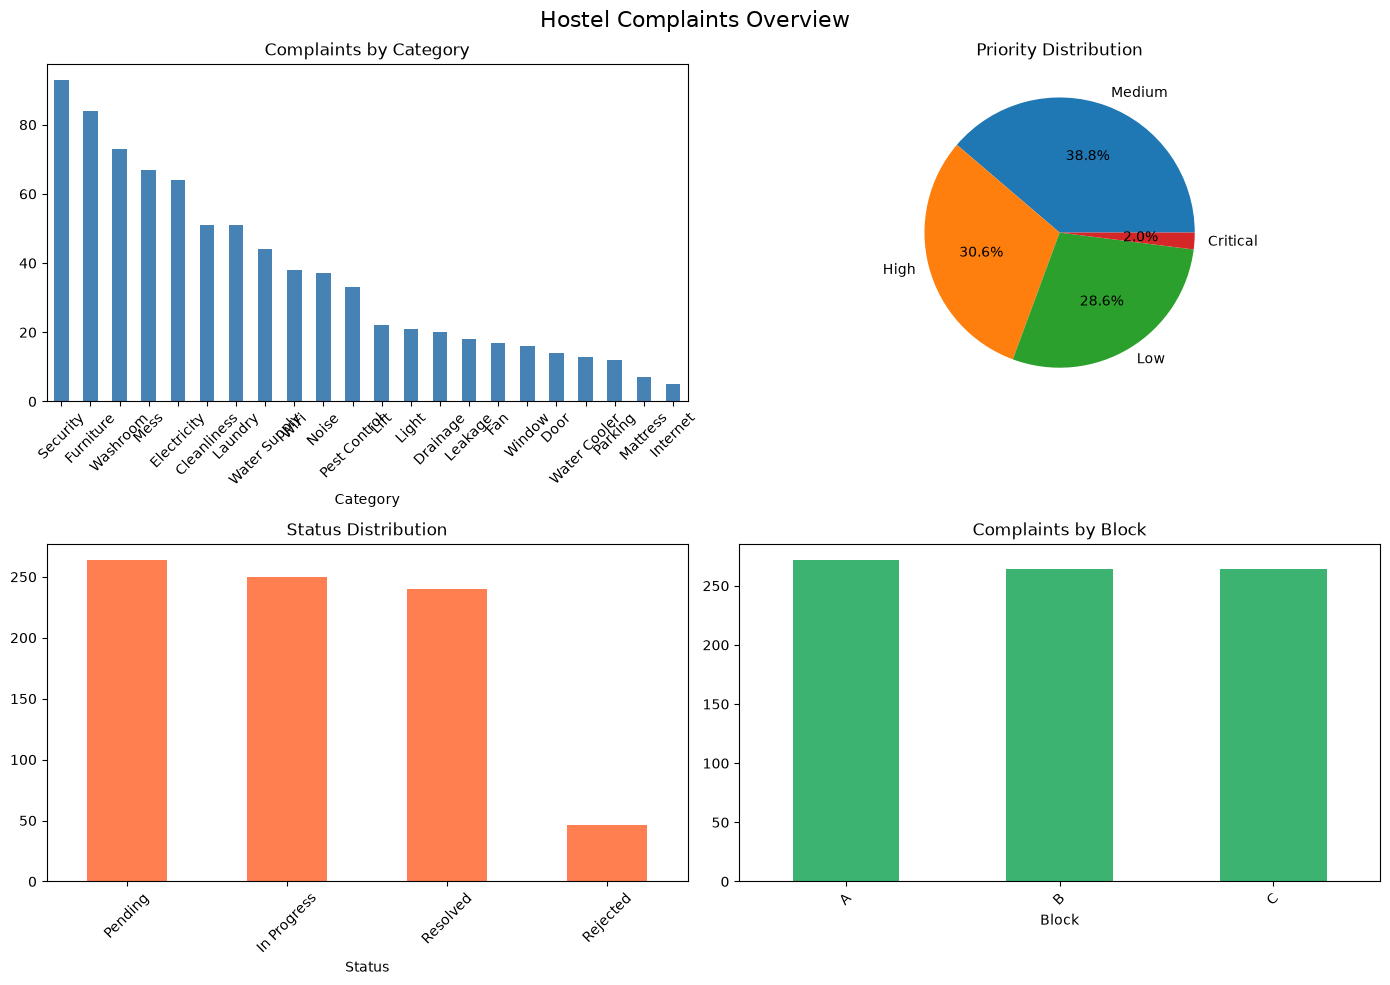

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Hostel Complaints Overview', fontsize=16)

df['Category'].value_counts().plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Complaints by Category')
axes[0, 0].tick_params(axis='x', rotation=45)

df['Priority'].value_counts().plot(kind='pie', ax=axes[0, 1], autopct='%1.1f%%')
axes[0, 1].set_title('Priority Distribution')

df['Status'].value_counts().plot(kind='bar', ax=axes[1, 0], color='coral')
axes[1, 0].set_title('Status Distribution')
axes[1, 0].tick_params(axis='x', rotation=45)

df['Block'].value_counts().plot(kind='bar', ax=axes[1, 1], color='mediumseagreen')
axes[1, 1].set_title('Complaints by Block')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## SVM Model Evaluation
Self-contained cell: loads all artifacts from `saved_model/`, reconstructs the test split,
then evaluates without retraining or reloading the dataset into training memory.

[STEP 0] All required files found.
[STEP 1] Artifacts loaded.
         Model type  : Pipeline (Pipeline)
[STEP 2] Class names from LabelEncoder: ['Critical', 'High', 'Low', 'Medium']
[STEP 3] Test split reconstructed.
         Train: 640 | Test: 160
[STEP 4] Predictions generated.

  SVM MODEL  |  TEST SET METRICS
  Accuracy  : 0.8250  (82.50%)
  Precision : 0.8259
  Recall    : 0.8250
  F1-Score  : 0.8248

  Overfitting Check
  Training Accuracy     : 0.9703  (97.03%)
  Testing  Accuracy     : 0.8250  (82.50%)
  Gap (Train - Test)    : 0.1453
  --> Significant overfitting. Consider more regularisation or more data.

  CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Critical       1.00      1.00      1.00         3
        High       0.79      0.86      0.82        49
         Low       0.87      0.85      0.86        46
      Medium       0.81      0.77      0.79        62

    accuracy                           0.82       160
   macro avg       0.87  

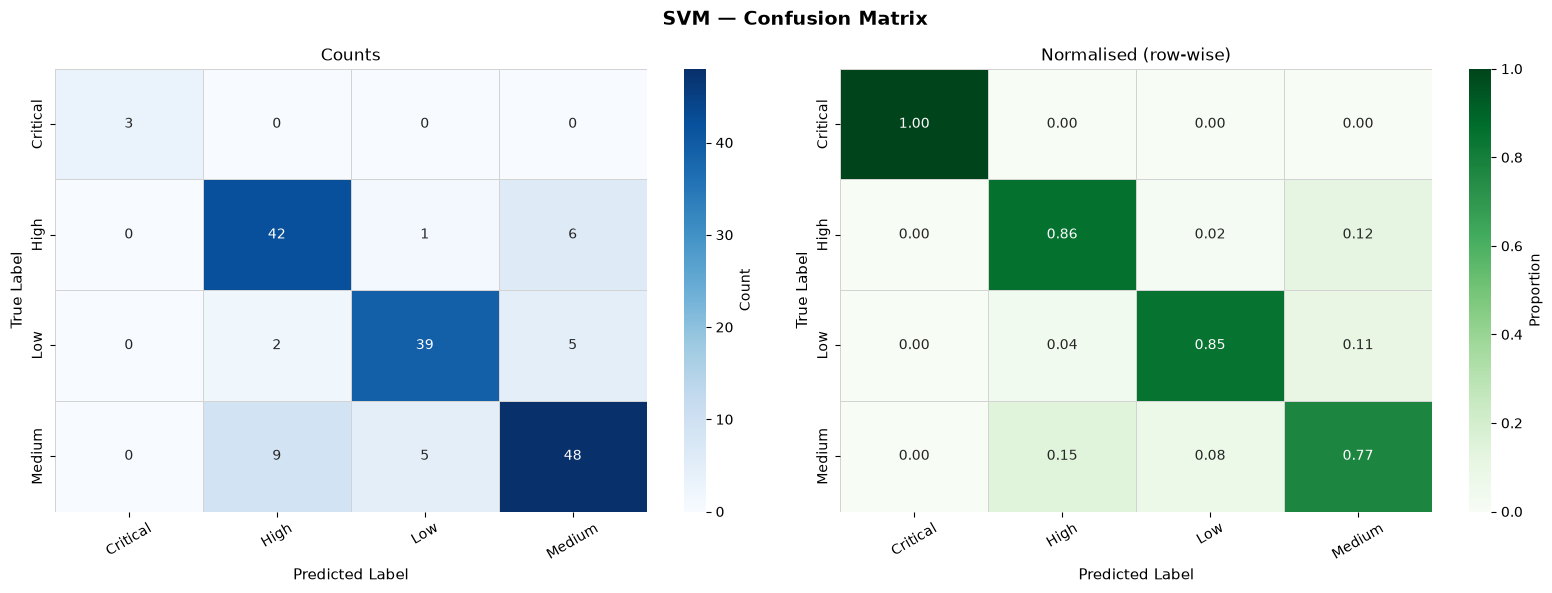

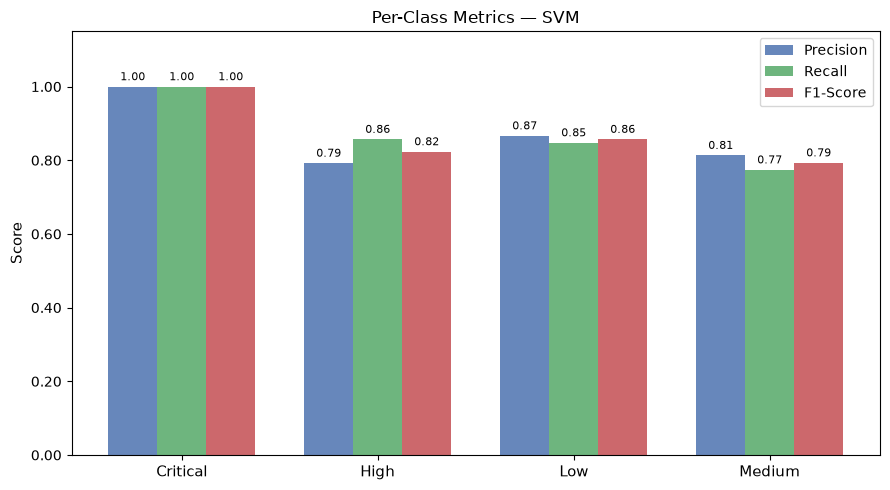


Evaluation complete.


In [31]:
# =============================================================================
# SVM MODEL EVALUATION — FULLY SELF-CONTAINED
# =============================================================================
# This cell:
#   - Detects and reports any missing saved artifacts before failing
#   - Loads the trained pipeline and label encoder from saved_model/
#   - Reconstructs the EXACT same test split (random_state=42) used in training
#   - Does NOT retrain, does NOT assume any variable from other cells
#   - Automatically uses class labels from LabelEncoder if available,
#     otherwise falls back to unique values in y_test
# =============================================================================

import os, re, sys, warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    precision_recall_fscore_support
)

warnings.filterwarnings("ignore")
nltk.download("stopwords", quiet=True)
nltk.download("wordnet",   quiet=True)
nltk.download("omw-1.4",   quiet=True)

# =============================================================================
# STEP 0 — Safety check: detect any missing artifacts BEFORE crashing
# =============================================================================
MODEL_DIR = "saved_model"
REQUIRED = {
    "model"    : os.path.join(MODEL_DIR, "hostel_priority_model.pkl"),
    "encoder"  : os.path.join(MODEL_DIR, "label_encoder.pkl"),
    "stopwords": os.path.join(MODEL_DIR, "domain_stopwords.pkl"),
}
CSV_PATH = "hostel_complaints_800_final (1).csv"

missing = []
if not os.path.isdir(MODEL_DIR):
    missing.append("Directory '%s/' not found. Run standalone_train_save.py first." % MODEL_DIR)
else:
    for name, path in REQUIRED.items():
        if not os.path.isfile(path):
            missing.append("Missing: %s  -> Run standalone_train_save.py to generate it." % path)
if not os.path.isfile(CSV_PATH):
    missing.append("Missing CSV: %s" % CSV_PATH)

if missing:
    print("ERROR — Cannot run evaluation. The following are missing:")
    for m in missing:
        print("  *", m)
    raise SystemExit(1)

print("[STEP 0] All required files found.")

# =============================================================================
# STEP 1 — Load saved artifacts
# =============================================================================
model          = joblib.load(REQUIRED["model"])
label_encoder  = joblib.load(REQUIRED["encoder"])
domain_sw      = joblib.load(REQUIRED["stopwords"])

model_type = type(model).__name__

# Detect whether model is a Pipeline or bare estimator
from sklearn.pipeline import Pipeline
is_pipeline = isinstance(model, Pipeline)

print("[STEP 1] Artifacts loaded.")
print("         Model type  :", model_type, "(Pipeline)" if is_pipeline else "(bare estimator)")

# =============================================================================
# STEP 2 — Determine class names
#   If LabelEncoder exists and has .classes_, use those (original string labels).
#   Otherwise, use unique values from y_test after reconstruction.
# =============================================================================
has_encoder = hasattr(label_encoder, "classes_")
if has_encoder:
    class_names = label_encoder.classes_
    print("[STEP 2] Class names from LabelEncoder:", class_names.tolist())
else:
    class_names = None   # will be set after y_test is built
    print("[STEP 2] No LabelEncoder classes found; will infer from y_test.")

# =============================================================================
# STEP 3 — Reconstruct the EXACT test split used during training
#   We re-read the CSV, apply identical preprocessing, and call train_test_split
#   with the SAME parameters (test_size=0.20, random_state=42, stratify=y).
#   This guarantees X_test_raw / y_test match what the model was evaluated on.
# =============================================================================
df = pd.read_csv(CSV_PATH)

# NLP preprocessing — identical to standalone_train_save.py
std_sw     = set(stopwords.words("english"))
all_sw     = std_sw.union(domain_sw)
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [lemmatizer.lemmatize(w) for w in text.split()
              if w not in all_sw and len(w) > 2]
    return " ".join(tokens)

df["Cleaned_Text"] = df["Complaint_Text"].apply(preprocess_text)

# Encode target (same label_encoder from saved_model/)
y = label_encoder.transform(df["Priority"])

# Drop same columns as in training
drop_cols = [c for c in
             ["Complaint_ID","Room_No","Duration","Status",
              "Complaint_Date","Complaint_Text","Priority"]
             if c in df.columns]
X = df.drop(columns=drop_cols)

# Reproduce the 80/20 split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("[STEP 3] Test split reconstructed.")
print("         Train:", len(X_train_raw), "| Test:", len(X_test_raw))

# Set class_names from y_test if no LabelEncoder
if class_names is None:
    unique_enc = np.unique(y_test)
    class_names = label_encoder.inverse_transform(unique_enc) if has_encoder else unique_enc
    print("         Class names (inferred):", class_names.tolist())

# =============================================================================
# STEP 4 — Predictions  (NO retraining)
# =============================================================================
# Pipeline.predict() runs preprocessor + model internally.
# Bare estimator needs preprocessed features — handled by the pipeline check above.
y_pred_test  = model.predict(X_test_raw)
y_pred_train = model.predict(X_train_raw)
print("[STEP 4] Predictions generated.")

# =============================================================================
# STEP 5 — Core metrics on the test set
# =============================================================================
accuracy  = accuracy_score(y_test,  y_pred_test)
precision = precision_score(y_test, y_pred_test, average="weighted", zero_division=0)
recall    = recall_score(y_test,    y_pred_test, average="weighted", zero_division=0)
f1        = f1_score(y_test,        y_pred_test, average="weighted", zero_division=0)

print("\n" + "="*56)
print("  SVM MODEL  |  TEST SET METRICS")
print("="*56)
print("  Accuracy  : %.4f  (%.2f%%)" % (accuracy, accuracy * 100))
print("  Precision : %.4f" % precision)
print("  Recall    : %.4f" % recall)
print("  F1-Score  : %.4f" % f1)
print("="*56)

# =============================================================================
# STEP 6 — Overfitting check  (Training accuracy vs Testing accuracy)
#   A large gap means the model memorised training data but failed to generalise.
# =============================================================================
train_acc = accuracy_score(y_train, y_pred_train)
test_acc  = accuracy_score(y_test,  y_pred_test)
gap       = train_acc - test_acc

print("\n  Overfitting Check")
print("  %-22s: %.4f  (%.2f%%)" % ("Training Accuracy", train_acc, train_acc * 100))
print("  %-22s: %.4f  (%.2f%%)" % ("Testing  Accuracy", test_acc,  test_acc  * 100))
print("  %-22s: %.4f" % ("Gap (Train - Test)", gap))
if gap < 0.05:
    print("  --> No significant overfitting. Model generalises well.")
elif gap < 0.10:
    print("  --> Slight overfitting detected.")
else:
    print("  --> Significant overfitting. Consider more regularisation or more data.")

# =============================================================================
# STEP 7 — Full Classification Report  (per-class precision, recall, F1)
# =============================================================================
print("\n" + "="*56)
print("  CLASSIFICATION REPORT")
print("="*56)
print(classification_report(
    y_test, y_pred_test,
    target_names=class_names,   # original string labels from LabelEncoder
    zero_division=0
))

# =============================================================================
# STEP 8 — Confusion Matrix (counts + normalised, side by side)
# =============================================================================
cm      = confusion_matrix(y_test, y_pred_test)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("SVM — Confusion Matrix", fontsize=14, fontweight="bold")

# Left: raw counts
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=class_names, yticklabels=class_names,
    linewidths=0.5, linecolor="lightgrey",
    ax=axes[0], cbar_kws={"label": "Count"}
)
axes[0].set_title("Counts", fontsize=12)
axes[0].set_xlabel("Predicted Label", fontsize=11)
axes[0].set_ylabel("True Label", fontsize=11)
axes[0].tick_params(axis="x", rotation=30)

# Right: normalised proportions
sns.heatmap(
    cm_norm, annot=True, fmt=".2f", cmap="Greens",
    xticklabels=class_names, yticklabels=class_names,
    linewidths=0.5, linecolor="lightgrey",
    ax=axes[1], vmin=0, vmax=1, cbar_kws={"label": "Proportion"}
)
axes[1].set_title("Normalised (row-wise)", fontsize=12)
axes[1].set_xlabel("Predicted Label", fontsize=11)
axes[1].set_ylabel("True Label", fontsize=11)
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

# =============================================================================
# STEP 9 — Per-class bar chart: Precision / Recall / F1
# =============================================================================
precisions, recalls, f1s, _ = precision_recall_fscore_support(
    y_test, y_pred_test,
    labels=np.arange(len(class_names)),
    zero_division=0
)

x     = np.arange(len(class_names))
width = 0.25

fig2, ax = plt.subplots(figsize=(9, 5))
bp = ax.bar(x - width, precisions, width, label="Precision", color="#4C72B0", alpha=0.85)
br = ax.bar(x,         recalls,   width, label="Recall",    color="#55A868", alpha=0.85)
bf = ax.bar(x + width, f1s,       width, label="F1-Score",  color="#C44E52", alpha=0.85)

for bars in [bp, br, bf]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                "%.2f" % h, ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(class_names, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Per-Class Metrics — SVM", fontsize=12)
ax.legend(loc="upper right")
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
plt.tight_layout()
plt.show()

print("\nEvaluation complete.")
